# Feature Engineering

**Notebook 03 — Phase 1**

## Executive Summary

Engineer eight domain-informed HR features using fixed bins, compare signal vs original features, and persist enriched datasets.

## Objectives

- Create meaningful HR features with business motivation
- Apply row-wise transforms without test-set statistics
- Compare original vs engineered predictive signal

## Expected Outputs

- `data/interim/train_features.csv` and `test_features.csv`

## Required Inputs

- Run from the **project root** with the virtual environment activated (`make install`).
- Prerequisites: Notebook 02 (`data/interim/train.csv`, `test.csv`)
- Reproducibility: `RANDOM_STATE = 42` where applicable.

## Methodology

Fixed domain bins and row-wise transforms — no statistics from the test set.


## 1. Setup and Load Splits

In [1]:
import sys
from pathlib import Path

_root = Path.cwd()
if not (_root / "data" / "raw").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from notebooks._shared.config import FEATURE_CFG, INTERIM_DIR, SATISFACTION_INDEX_COLS, TARGET
from notebooks._shared.features import FEATURE_DEFINITIONS
from notebooks._shared.plotting import attrition_rate_by, setup_plot_style

setup_plot_style()
train_df = pd.read_csv(INTERIM_DIR / "train.csv")
test_df = pd.read_csv(INTERIM_DIR / "test.csv")
print(f"Train: {train_df.shape} | Test: {test_df.shape}")


Train: (1176, 31) | Test: (294, 31)


## 2. Feature Definitions

**Objective:** Document engineered features before implementation.

In [2]:
feature_docs = pd.DataFrame(
    [{"Feature": k, "Definition": v} for k, v in FEATURE_DEFINITIONS.items()]
)
feature_docs

,Feature,Definition
0,IncomePerExperience,MonthlyIncome divided by (TotalWorkingYears + 1).
1,PromotionGap,YearsAtCompany minus YearsSinceLastPromotion.
2,CareerStage,"Early (0-3 yrs), Mid (4-10 yrs), Senior (10+ y..."
3,CompensationGrowth,PercentSalaryHike multiplied by YearsAtCompany.
4,SatisfactionIndex,"Mean of EnvironmentSatisfaction, JobSatisfacti..."
5,OvertimeRisk,Binary: 1 if OverTime=Yes AND WorkLifeBalance ...
6,TenureBand,"New (0-2), Established (3-5), Veteran (6-10), ..."
7,CareerVelocity,JobLevel divided by (TotalWorkingYears + 1).


## 3. Implementation — Feature Engineering

**Objective:** Create 8 HR features on each split independently.

**Methodology:** Fixed domain bins — no quantiles from data (leakage-safe).

**Mathematical reasoning:** All transforms are per-row (ratios, differences, fixed thresholds).

In [3]:

def assign_binned_category(series, bins):
    """Assign fixed domain bins (no data-driven quantiles)."""
    result = pd.Series(index=series.index, dtype="object")
    for label, bounds in bins.items():
        low, high = bounds
        result[(series >= low) & (series <= high)] = label
    return result.fillna("Unknown")


def engineer_features(df, cfg=None):
    """Create eight HR features using fixed domain rules (row-wise, leakage-safe)."""
    cfg = cfg or FEATURE_CFG
    out = df.copy()
    out["IncomePerExperience"] = out["MonthlyIncome"] / (out["TotalWorkingYears"] + 1)
    out["PromotionGap"] = out["YearsAtCompany"] - out["YearsSinceLastPromotion"]
    out["CareerStage"] = assign_binned_category(out["TotalWorkingYears"], cfg["career_stage_bins"])
    out["CompensationGrowth"] = out["PercentSalaryHike"] * out["YearsAtCompany"]
    out["SatisfactionIndex"] = out[SATISFACTION_INDEX_COLS].mean(axis=1)
    out["OvertimeRisk"] = ((out["OverTime"] == "Yes") & (out["WorkLifeBalance"] <= 2)).astype(int)
    out["TenureBand"] = assign_binned_category(out["YearsAtCompany"], cfg["tenure_band_bins"])
    out["CareerVelocity"] = out["JobLevel"] / (out["TotalWorkingYears"] + 1)
    return out


train_fe = engineer_features(train_df)
test_fe = engineer_features(test_df)

new_cols = list(FEATURE_DEFINITIONS.keys())
print("Engineered columns:", new_cols)
train_fe[new_cols].head()


Engineered columns: ['IncomePerExperience', 'PromotionGap', 'CareerStage', 'CompensationGrowth', 'SatisfactionIndex', 'OvertimeRisk', 'TenureBand', 'CareerVelocity']


,IncomePerExperience,PromotionGap,CareerStage,CompensationGrowth,SatisfactionIndex,OvertimeRisk,TenureBand,CareerVelocity
0,532.400000,2,Senior,42,2.50,0,Established,0.133333
1,630.750000,0,Early,28,3.25,0,New,0.250000
2,727.708333,8,Senior,144,2.75,0,LongTenure,0.166667
3,262.000000,7,Mid,77,2.75,0,Veteran,0.125000
4,516.272727,4,Mid,104,3.00,0,Veteran,0.181818


## 4. Compare Original vs Engineered Signal

**Objective:** Assess whether engineered features capture attrition patterns.

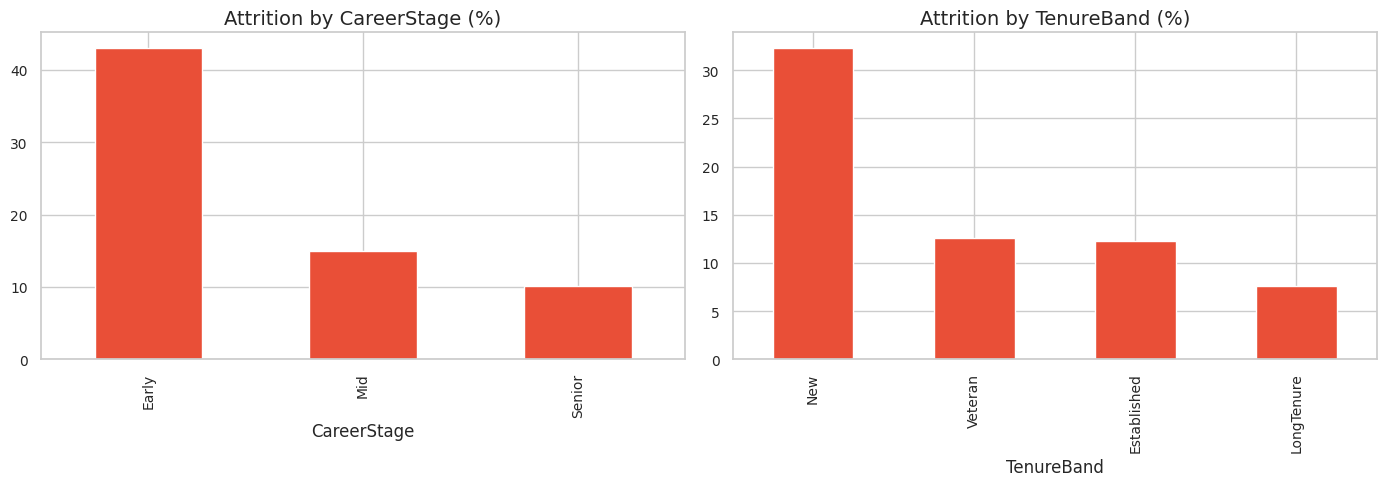

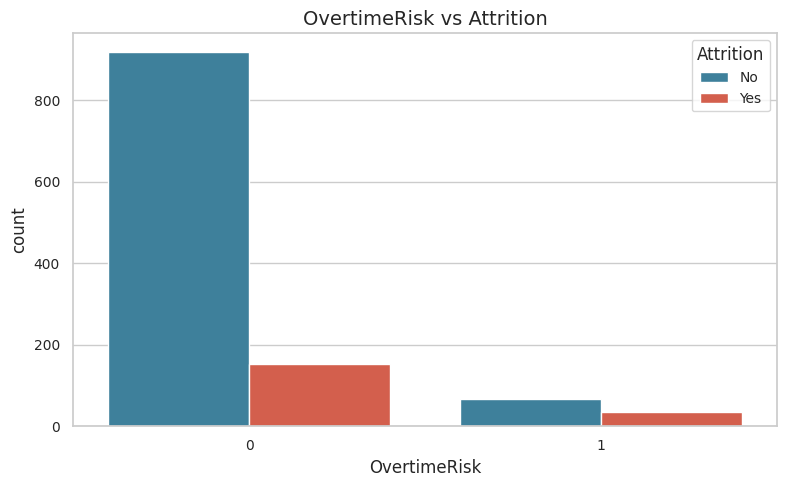

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
attrition_rate_by(train_fe, "CareerStage").plot(kind="bar", ax=axes[0], color="#E94F37")
axes[0].set_title("Attrition by CareerStage (%)")
attrition_rate_by(train_fe, "TenureBand").plot(kind="bar", ax=axes[1], color="#E94F37")
axes[1].set_title("Attrition by TenureBand (%)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=train_fe, x="OvertimeRisk", hue=TARGET, palette={"No": "#2E86AB", "Yes": "#E94F37"}, ax=ax)
ax.set_title("OvertimeRisk vs Attrition")
plt.tight_layout()
plt.show()

**Interpretation:** Early career stages, new tenure bands, and overtime risk correlate with higher attrition.

**Expected predictive value:** Composite features capture HR narratives (compensation efficiency, promotion stagnation, burnout risk).

**Conclusion:** Engineered features add domain signal beyond raw columns.

### Observations

Eight engineered features added to both splits without using test-set statistics.

**Business Interpretation:** Features encode HR narratives — compensation efficiency, promotion stagnation, burnout risk, and career stage.



## 5. Persist Feature-Enriched Splits

In [5]:
train_path = INTERIM_DIR / "train_features.csv"
test_path = INTERIM_DIR / "test_features.csv"
train_fe.to_csv(train_path, index=False)
test_fe.to_csv(test_path, index=False)
print(f"Saved: {train_path.name} ({train_fe.shape}), {test_path.name} ({test_fe.shape})")

Saved: train_features.csv ((1176, 39)), test_features.csv ((294, 39))


## Conclusion

Feature-enriched splits are saved for modeling. All transforms are per-row and leakage-safe.

## Future Connection

Notebook 04 trains a logistic regression baseline inside a sklearn Pipeline. Encoding and scaling fit on the training set only.
